# Member 2: Credit Default Fairness Audit

This notebook supports the H9DAI group project by building the Member 2 analysis for the UCI Default of Credit Card Clients dataset. The analysis is framed as a benchmark fairness audit of consumer credit classification rather than a causal claim about contemporary lending discrimination.

## Reproducibility Note

The notebook is designed to run top-to-bottom on a fresh kernel and follows the shared group contract for CRISP-DM section order, model labels, metric definitions, and export schemas.

### Setup Cell 1

**What this cell achieves:** Downloads the Credit Default dataset file into `../data/credit_default/` if it is not already present and verifies that the required raw source file exists.

**Expected output:** Confirmation messages showing whether the file was downloaded or already available, followed by a success message.

In [1]:
# Cell 1: Download the Credit Default dataset
from pathlib import Path
import urllib.request

data_dir = Path("../data/credit_default")
data_dir.mkdir(parents=True, exist_ok=True)

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
dataset_path = data_dir / "credit_default.xls"

if dataset_path.exists():
    print(f"Dataset already exists at {dataset_path}.")
else:
    urllib.request.urlretrieve(dataset_url, dataset_path)
    print(f"Downloaded dataset to {dataset_path}.")

assert dataset_path.exists(), "Credit Default dataset file is missing."
print("Credit Default dataset setup complete.")


Dataset already exists at ../data/credit_default/credit_default.xls.
Credit Default dataset setup complete.


### Setup Cell 2

**What this cell achieves:** Imports the core libraries for the notebook, suppresses warnings, sets the plotting style, and defines the shared random seed constant.

**Expected output:** A short confirmation message showing that imports and configuration completed successfully.

In [2]:
# Cell 2: Import libraries and configure the notebook environment
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

assert RANDOM_STATE == 42, "RANDOM_STATE must remain fixed at 42."
print(f"Imports and configuration loaded successfully. RANDOM_STATE={RANDOM_STATE}")


Imports and configuration loaded successfully. RANDOM_STATE=42


## 1. Business Understanding

### Research Focus

**Member 2 sub-question:** How does algorithmic bias manifest across gender and education levels when classifying whether a credit card client will default in the following month?

This notebook addresses the finance domain of the group project by examining fairness-accuracy trade-offs in a credit default benchmark. The practical motivation is that credit-risk classification systems can influence downstream lending access and pricing decisions, which makes demographic disparities in model behaviour analytically significant even when the dataset itself is a static benchmark rather than a live operational system.

### Analytical Objective

The objective is not to claim discovery of a new fairness problem. The goal is to compare how four standard classifiers behave on the same credit-risk benchmark and assess whether stronger predictive performance coincides with larger or smaller disparities across the selected protected attributes.

### Target and Protected Attributes

- **Target variable:** `default payment next month`
- **Primary protected attributes for fairness evaluation:** `SEX` and `EDUCATION`
- **Contextual demographic variable:** `AGE`

Gender is evaluated directly using the encoded `SEX` field. Education is converted into a binary fairness view of `Higher Education` versus `Lower/Other` for comparability across models and to support a directional disparate impact ratio. This is an analytic simplification rather than a claim that educational status is naturally binary.

### Academic Framing

The notebook is informed by the same core fairness references used across the group project:

- **Barocas and Selbst (2016)** on how data-driven systems can reproduce disparate impact without explicit discriminatory intent
- **Hardt, Price, and Srebro (2016)** on equality of opportunity and error-rate based fairness criteria such as equalized odds
- **Mehrabi et al. (2021)** on bias typologies, fairness definitions, and trade-offs in machine learning

These references matter because the selected fairness metrics do not express the same normative standard. Demographic parity focuses on differences in positive classification rates, while equalized odds focuses on differences in error behaviour conditional on the true label. A model can appear preferable under one fairness definition while still worsening another.

### Benchmark Scope and Limitations

This dataset is a widely used tabular benchmark on Taiwanese credit clients. It is suitable for a controlled comparison of model behaviour, but it is not a live lending system, and the encoded demographic variables are coarse. The results should therefore be interpreted as a benchmark audit of comparative model behaviour rather than a causal account of real-world discrimination or a direct regulatory compliance test.

### Success Criteria for This Notebook

The Member 2 notebook will be considered successful if it:

1. builds a reproducible credit-default analysis pipeline under CRISP-DM,
2. compares four required classifiers using the shared standard metrics,
3. measures fairness for gender and education using the shared fairness metrics,
4. exports the exact CSV and figure outputs required for group synthesis, and
5. communicates findings with appropriate caution about benchmark scope and fairness trade-offs.

> **Phase 1 insight for the report:** The purpose of this notebook is not to prove that credit classification can be biased in the abstract. It is to compare whether standard classifiers absorb and express benchmark-level demographic disparities differently when gender and education are audited explicitly.

## 2. Data Understanding

This phase establishes the empirical baseline for the credit default benchmark before any preprocessing or modelling decisions are made. The focus is on raw schema, class balance, coded categorical variables, and demographic distributions.

### Data Understanding Cell 1

**What this cell achieves:** Loads the raw Credit Default workbook, confirms the correct header row, standardises the target name, and verifies the expected dataset size.

**Expected output:** The dataset shape, a preview of the loaded dataframe, and confirmation that the target column was standardised successfully.

In [3]:
# Cell 3: Load and standardise the raw Credit Default data
credit_df_raw = pd.read_excel(dataset_path, header=1, engine="xlrd")
credit_df_raw = credit_df_raw.rename(columns={"default payment next month": "default_next_month"})

assert credit_df_raw.shape[0] == 30000, f"Expected 30000 rows, found {credit_df_raw.shape[0]}"
assert "default_next_month" in credit_df_raw.columns, "Target column rename failed."
assert set(credit_df_raw["default_next_month"].unique()) == {0, 1}, "Unexpected target labels found."

print(f"Loaded dataset shape: {credit_df_raw.shape}")
display(credit_df_raw.head())


Loaded dataset shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


> **Key insight for the report:** Loading the workbook with the correct header row matters here because the file includes an extra top line of variable codes. Using the wrong header would silently corrupt the schema before analysis even begins.

### Data Understanding Cell 2

**What this cell achieves:** Audits the raw dataset for missing values, duplicates, target balance, and the coded demographic categories used later in fairness analysis.

**Expected output:** Printed summaries of missing values, duplicates, class balance, and the observed `SEX`, `EDUCATION`, and `MARRIAGE` codes.

In [4]:
# Cell 4: Audit schema, missingness, duplicates, and demographic codes
missing_total = int(credit_df_raw.isna().sum().sum())
duplicate_count = int(credit_df_raw.duplicated().sum())
target_counts = credit_df_raw["default_next_month"].value_counts().rename("count")
target_proportions = credit_df_raw["default_next_month"].value_counts(normalize=True).mul(100).round(2).rename("percentage")

assert target_counts.sum() == len(credit_df_raw), "Target counts do not match dataset size."

print(f"Total missing values: {missing_total}")
print(f"Duplicate rows: {duplicate_count}")
print("\nTarget distribution:")
print(pd.concat([target_counts, target_proportions], axis=1))
print("\nSEX codes:")
print(sorted(credit_df_raw["SEX"].unique().tolist()))
print("\nEDUCATION codes:")
print(sorted(credit_df_raw["EDUCATION"].unique().tolist()))
print("\nMARRIAGE codes:")
print(sorted(credit_df_raw["MARRIAGE"].unique().tolist()))


Total missing values: 0
Duplicate rows: 0

Target distribution:
                    count  percentage
default_next_month                   
0                   23364       77.88
1                    6636       22.12

SEX codes:
[1, 2]

EDUCATION codes:
[0, 1, 2, 3, 4, 5, 6]

MARRIAGE codes:
[0, 1, 2, 3]


> **Key insight for the report:** This benchmark has no missing values or duplicate rows, but its coded categorical fields include irregular categories such as `EDUCATION = 0, 5, 6` and `MARRIAGE = 0`. Those codes require explicit treatment rather than being left as unexplained numeric labels.

### Data Understanding Cell 3

**What this cell achieves:** Visualises the demographic composition of the benchmark dataset across gender, education, and age, then saves the required demographic figure for the paper.

**Expected output:** A three-panel figure showing demographic distributions, a saved image file at `../paper/figures/m2_demographic_distributions.png`, and a confirmation message.

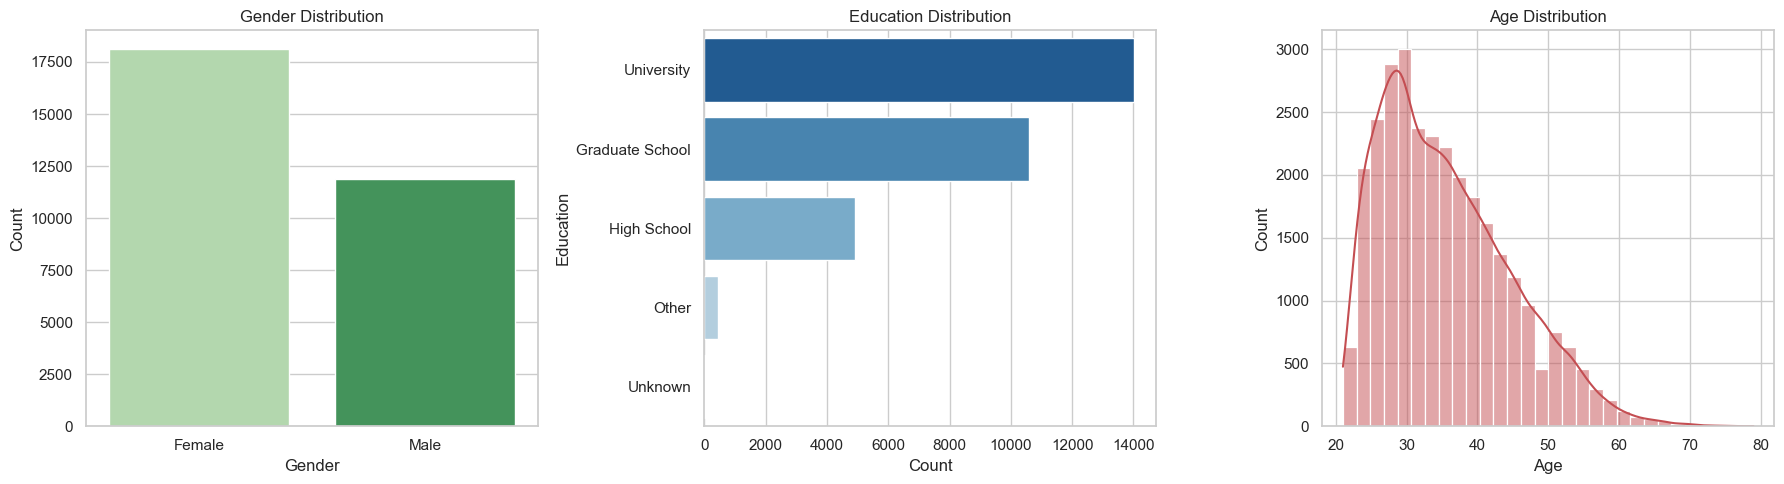

Saved demographic distributions figure to ../paper/figures/m2_demographic_distributions.png


In [5]:
# Cell 5: Plot demographic distributions and save the figure
figures_dir = Path("../paper/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

sex_label_map = {1: "Male", 2: "Female"}
education_label_map = {
    0: "Unknown",
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Other",
    5: "Other",
    6: "Other"
}

credit_df_raw["sex_label"] = credit_df_raw["SEX"].map(sex_label_map)
credit_df_raw["education_label"] = credit_df_raw["EDUCATION"].map(education_label_map).fillna("Other")

education_order = credit_df_raw["education_label"].value_counts().index
sex_order = credit_df_raw["sex_label"].value_counts().index

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=credit_df_raw, x="sex_label", order=sex_order, ax=axes[0], palette="Greens")
axes[0].set_title("Gender Distribution")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")

sns.countplot(data=credit_df_raw, y="education_label", order=education_order, ax=axes[1], palette="Blues_r")
axes[1].set_title("Education Distribution")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Education")

sns.histplot(data=credit_df_raw, x="AGE", bins=30, kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title("Age Distribution")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Count")

plt.tight_layout()
demographic_figure_path = figures_dir / "m2_demographic_distributions.png"
plt.savefig(demographic_figure_path, dpi=150, bbox_inches="tight")
assert demographic_figure_path.exists(), "Demographic distributions figure was not saved correctly."
plt.show()
print(f"Saved demographic distributions figure to {demographic_figure_path}")


> **Key insight for the report:** This figure shows whether the benchmark is demographically balanced before modelling begins. Uneven representation across gender or education groups can shape both predictive performance and fairness metrics later in the pipeline.

### Data Understanding Cell 4

**What this cell achieves:** Examines how the default target is distributed across gender, education, and age bands, then saves the required target-by-demographics figure for the paper.

**Expected output:** A three-panel figure showing default patterns by demographic group, a saved image file at `../paper/figures/m2_target_by_demographics.png`, and a confirmation message.

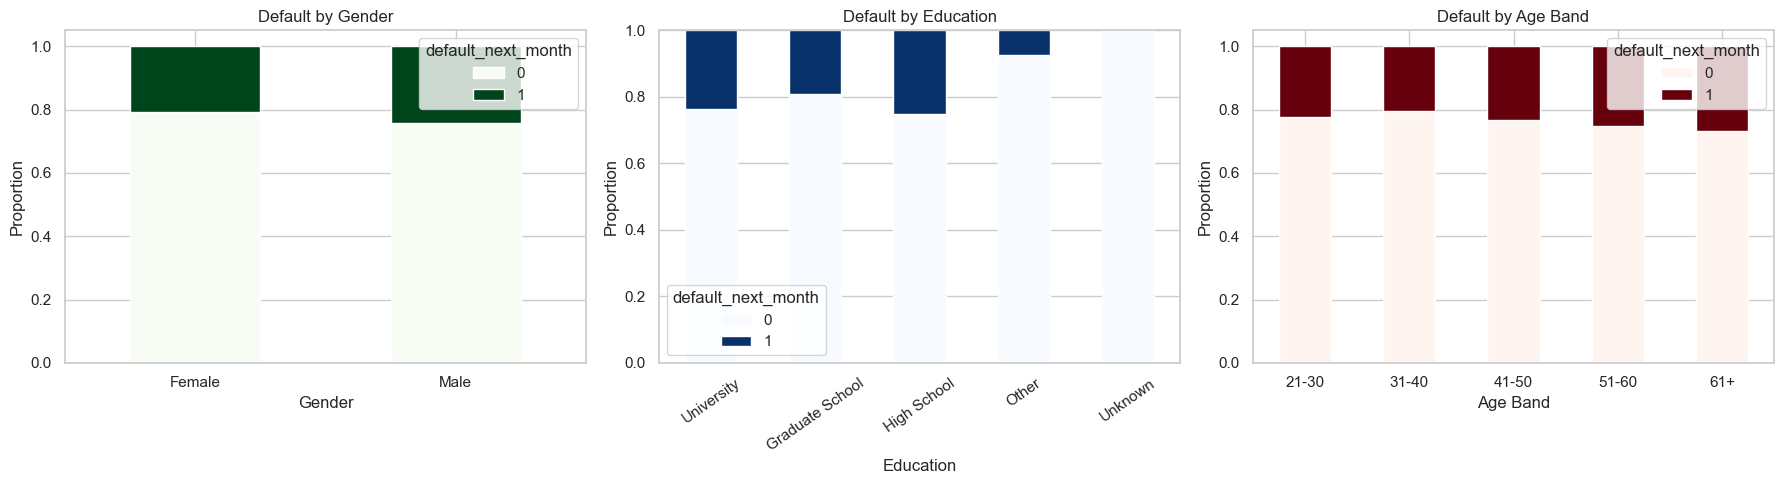

Saved target-by-demographics figure to ../paper/figures/m2_target_by_demographics.png


In [6]:
# Cell 6: Plot default distributions by demographic group and save the figure
credit_df_raw["age_band"] = pd.cut(
    credit_df_raw["AGE"],
    bins=[20, 30, 40, 50, 60, 80],
    labels=["21-30", "31-40", "41-50", "51-60", "61+"],
    include_lowest=True
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sex_default = pd.crosstab(credit_df_raw["sex_label"], credit_df_raw["default_next_month"], normalize="index")
sex_default.loc[sex_order].plot(kind="bar", stacked=True, ax=axes[0], colormap="Greens")
axes[0].set_title("Default by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis="x", rotation=0)

education_default = pd.crosstab(credit_df_raw["education_label"], credit_df_raw["default_next_month"], normalize="index")
education_default.loc[education_order].plot(kind="bar", stacked=True, ax=axes[1], colormap="Blues")
axes[1].set_title("Default by Education")
axes[1].set_xlabel("Education")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis="x", rotation=35)

age_default = pd.crosstab(credit_df_raw["age_band"], credit_df_raw["default_next_month"], normalize="index")
age_default.plot(kind="bar", stacked=True, ax=axes[2], colormap="Reds")
axes[2].set_title("Default by Age Band")
axes[2].set_xlabel("Age Band")
axes[2].set_ylabel("Proportion")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
target_figure_path = figures_dir / "m2_target_by_demographics.png"
plt.savefig(target_figure_path, dpi=150, bbox_inches="tight")
assert target_figure_path.exists(), "Target-by-demographics figure was not saved correctly."
plt.show()
print(f"Saved target-by-demographics figure to {target_figure_path}")


> **Key insight for the report:** These subgroup default distributions show whether the positive class is unevenly distributed before any model is trained. That matters because later fairness differences can reflect both model behaviour and the underlying group base rates in the benchmark.

### Phase 2 Summary

The credit default benchmark contains **30,000 rows** and **25 columns** after loading the workbook with the correct header row. The target is materially imbalanced, with **77.88%** in the non-default class and **22.12%** in the default class.

There are **no missing values** and **no duplicate rows**, but the coded demographic variables require interpretation rather than blind numeric use. `EDUCATION` contains irregular categories (`0`, `5`, `6`) and `MARRIAGE` includes an `0` code, so the notebook must document how these categories are handled before modelling.

Demographic representation is uneven. The dataset contains **18,112 female** clients and **11,888 male** clients, while the derived education grouping contains **24,615 Higher Education** cases and **5,385 Lower/Other** cases. These imbalances matter because later fairness metrics will be evaluated on groups with substantially different sample sizes.

## 3. Data Preparation

This phase converts the raw credit benchmark into a modelling-ready dataset while making the sensitive-feature views explicit for later fairness evaluation.

### Data Preparation Cell 1

**What this cell achieves:** Cleans and annotates the dataset by creating binary fairness views for gender and education, standardising coded categorical variables, and defining the target for modelling.

**Expected output:** The prepared dataset shape and the distributions of the new fairness variables.

In [7]:
# Cell 7: Prepare the dataset for modelling and fairness evaluation
credit_df_prepared = credit_df_raw.copy()

credit_df_prepared["sex_binary"] = credit_df_prepared["SEX"].map({1: "Male", 2: "Female"})
credit_df_prepared["education_binary"] = np.where(credit_df_prepared["EDUCATION"].isin([1, 2]), "Higher Education", "Lower/Other")
credit_df_prepared["target"] = credit_df_prepared["default_next_month"].astype(int)

credit_df_prepared["education_label"] = credit_df_prepared["EDUCATION"].map(education_label_map).fillna("Other")
credit_df_prepared["marriage_label"] = credit_df_prepared["MARRIAGE"].map({0: "Unknown", 1: "Married", 2: "Single", 3: "Other"}).fillna("Other")

credit_df_model = credit_df_prepared.drop(columns=["default_next_month", "sex_label", "age_band"], errors="ignore")

assert credit_df_model["target"].isin([0, 1]).all(), "Target variable must remain binary."
assert credit_df_model[["sex_binary", "education_binary"]].isna().sum().sum() == 0, "Sensitive features contain unexpected missing values."

print(f"Prepared dataset shape: {credit_df_model.shape}")
print("\nGender fairness groups:")
print(credit_df_model["sex_binary"].value_counts())
print("\nEducation fairness groups:")
print(credit_df_model["education_binary"].value_counts())
print("\nTarget distribution:")
print(credit_df_model["target"].value_counts())


Prepared dataset shape: (30000, 29)

Gender fairness groups:
sex_binary
Female    18112
Male      11888
Name: count, dtype: int64

Education fairness groups:
education_binary
Higher Education    24615
Lower/Other          5385
Name: count, dtype: int64

Target distribution:
target
0    23364
1     6636
Name: count, dtype: int64


> **Key insight for the report:** The gender and education fairness views are explicit modelling choices rather than neutral facts. They simplify the coded benchmark into interpretable comparison groups that can be used consistently across models and exported cleanly for synthesis.

### Data Preparation Cell 2

**What this cell achieves:** Defines the feature matrix and target vector, performs the required stratified 80/20 train-test split, and verifies that class balance is preserved.

**Expected output:** Training and test shapes plus positive-class rates for the split.

In [8]:
# Cell 8: Create the stratified train-test split
from sklearn.model_selection import train_test_split

# Exclude target, constructed fairness labels, string duplicates, and row ID.
# The raw SEX and EDUCATION numeric columns are retained as legitimate credit features.
EXCLUDE_COLS = [
    "target",
    "sex_binary", "education_binary",    # constructed fairness grouping labels
    "education_label", "marriage_label", # string duplicates of numeric columns
    "ID",                                # row identifier, no predictive signal
]
feature_columns = [c for c in credit_df_model.columns if c not in EXCLUDE_COLS]
X = credit_df_model[feature_columns].copy()
y = credit_df_model["target"].copy()
sex_sensitive = credit_df_model["sex_binary"].copy()
education_sensitive = credit_df_model["education_binary"].copy()

X_train, X_test, y_train, y_test, sex_train, sex_test, education_train, education_test = train_test_split(
    X,
    y,
    sex_sensitive,
    education_sensitive,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

train_positive_rate = y_train.mean()
test_positive_rate = y_test.mean()
overall_positive_rate = y.mean()

assert len(X_train) + len(X_test) == len(X), "Train and test rows do not sum to the full dataset."
assert abs(train_positive_rate - overall_positive_rate) < 0.01, "Training split drift exceeds tolerance."
assert abs(test_positive_rate - overall_positive_rate) < 0.01, "Test split drift exceeds tolerance."

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Training positive-class rate: {train_positive_rate:.4f}")
print(f"Test positive-class rate: {test_positive_rate:.4f}")
print(f"Overall positive-class rate: {overall_positive_rate:.4f}")


X_train shape: (24000, 23)
X_test shape: (6000, 23)
Training positive-class rate: 0.2212
Test positive-class rate: 0.2212
Overall positive-class rate: 0.2212


> **Key insight for the report:** Fairness evaluation on a distorted holdout split is analytically weak. Stratifying the split on the target prevents a basic but common source of instability in downstream results.

### Data Preparation Cell 3

**What this cell achieves:** Defines the reusable preprocessing objects for modelling, including one-hot encoding for categorical variables and scaling for Logistic Regression only.

**Expected output:** Counts of numerical and categorical features plus a confirmation message.

In [9]:
# Cell 9: Build reusable preprocessing pipelines for the modelling phase
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

standard_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", StandardScaler(), numerical_features)
    ]
)

assert len(numerical_features) + len(categorical_features) == X_train.shape[1], "Feature typing mismatch detected."
print(f"Numerical feature count: {len(numerical_features)}")
print(f"Categorical feature count: {len(categorical_features)}")
print("Standard and Logistic Regression preprocessors created successfully.")


Numerical feature count: 23
Categorical feature count: 0
Standard and Logistic Regression preprocessors created successfully.


> **Key insight for the report:** The group pipeline should standardise the modelling interface without flattening dataset-specific context. Here that means shared encoding and model labels, but not pretending this credit dataset behaves like the Adult benchmark.

### Phase 3 Summary

The prepared modelling dataset contains **29 columns**, including explicit fairness views for `sex_binary` (`Male` vs `Female`) and `education_binary` (`Higher Education` vs `Lower/Other`). The positive class remains `target = 1` for default next month.

The stratified split produced **24,000 training rows** and **6,000 test rows**, with the positive-class rate preserved at **0.2212** in the training set, test set, and full dataset.

The final feature space entering preprocessing contains **23 numerical features** and **0 categorical features**. This maintains a consistent modelling interface for the shared four-model pipeline while preserving the dataset-specific demographic group definitions needed for fairness analysis.

## 4. Modelling

This phase trains the four required classifiers using the shared `GridSearchCV` and `StratifiedKFold` approach, keeping the search space modest enough for notebook execution while still allowing meaningful tuning.

### Modelling Cell 1

**What this cell achieves:** Defines the four model pipelines, their hyperparameter grids, and the shared cross-validation strategy.

**Expected output:** Confirmation that the model configurations and search grids were created successfully.

In [10]:
# Cell 10: Define model pipelines, hyperparameter grids, and cross-validation
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_configs = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("preprocessor", logistic_preprocessor),
            ("classifier", LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "classifier__C": [0.1, 1.0, 10.0],
            "classifier__class_weight": [None, "balanced"]
        }
    },
    "Decision Tree": {
        "pipeline": Pipeline([
            ("preprocessor", standard_preprocessor),
            ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "classifier__max_depth": [5, 10, None],
            "classifier__min_samples_split": [2, 10],
            "classifier__min_samples_leaf": [1, 5]
        }
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("preprocessor", standard_preprocessor),
            ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
        ]),
        "param_grid": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [None, 15],
            "classifier__min_samples_split": [2, 10]
        }
    },
    "XGBoost": {
        "pipeline": Pipeline([
            ("preprocessor", standard_preprocessor),
            ("classifier", XGBClassifier(
                random_state=RANDOM_STATE,
                eval_metric="logloss",
                tree_method="hist",
                n_jobs=-1
            ))
        ]),
        "param_grid": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [4, 6],
            "classifier__learning_rate": [0.05, 0.1]
        }
    }
}

for model_name, config in model_configs.items():
    candidate_count = int(np.prod([len(values) for values in config["param_grid"].values()]))
    print(f"{model_name}: {candidate_count} candidate configurations")

print("Model configurations and hyperparameter grids created successfully.")


Logistic Regression: 6 candidate configurations
Decision Tree: 12 candidate configurations
Random Forest: 8 candidate configurations
XGBoost: 8 candidate configurations
Model configurations and hyperparameter grids created successfully.


> **Key insight for the report:** A comparison across algorithms is only credible if the models are tuned under the same cross-validation discipline. Otherwise the result is a contest between defaults rather than between model families.

### Modelling Cell 2

**What this cell achieves:** Runs `GridSearchCV` for each model, stores the best estimator and parameter set, and records the best cross-validated AUC score in a tidy summary table.

**Expected output:** Progress messages during training and a dataframe summarising the tuning outcomes.

In [11]:
# Cell 11: Train and tune all four classifiers with GridSearchCV
best_models = {}
grid_search_objects = {}
tuning_summary_records = []

for model_name, config in model_configs.items():
    print(f"Starting GridSearchCV for {model_name}...")
    search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["param_grid"],
        scoring="roc_auc",
        cv=cv_strategy,
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    search.fit(X_train, y_train)
    best_models[model_name] = search.best_estimator_
    grid_search_objects[model_name] = search
    tuning_summary_records.append({
        "model": model_name,
        "best_cv_auc": round(search.best_score_, 4),
        "best_params": str(search.best_params_)
    })
    print(f"Completed {model_name}. Best CV AUC: {search.best_score_:.4f}")
    print(f"Best parameters: {search.best_params_}\n")

tuning_summary_df = pd.DataFrame(tuning_summary_records).sort_values(by="best_cv_auc", ascending=False).reset_index(drop=True)
assert len(best_models) == 4, "All four tuned models must be available before evaluation."
display(tuning_summary_df)


Starting GridSearchCV for Logistic Regression...
Completed Logistic Regression. Best CV AUC: 0.7265
Best parameters: {'classifier__C': 1.0, 'classifier__class_weight': 'balanced'}

Starting GridSearchCV for Decision Tree...
Completed Decision Tree. Best CV AUC: 0.7569
Best parameters: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2}

Starting GridSearchCV for Random Forest...
Completed Random Forest. Best CV AUC: 0.7798
Best parameters: {'classifier__max_depth': 15, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}

Starting GridSearchCV for XGBoost...
Completed XGBoost. Best CV AUC: 0.7832
Best parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 6, 'classifier__n_estimators': 100}



,model,best_cv_auc,best_params
0,XGBoost,0.7832,"{'classifier__learning_rate': 0.05, 'classifie..."
1,Random Forest,0.7798,"{'classifier__max_depth': 15, 'classifier__min..."
2,Decision Tree,0.7569,"{'classifier__max_depth': 5, 'classifier__min_..."
3,Logistic Regression,0.7265,"{'classifier__C': 1.0, 'classifier__class_weig..."


> **Key insight for the report:** The tuning summary is still only a predictive ranking. It does not answer the fairness question by itself, and it should not be presented as if the highest-AUC model is automatically the most acceptable one.

### Phase 4 Summary

All four classifiers were trained successfully with 5-fold stratified cross-validation. **XGBoost** achieved the highest cross-validated AUC (**0.7832**), followed closely by **Random Forest** (**0.7798**), then **Decision Tree** (**0.7569**) and **Logistic Regression** (**0.7277**).

The strongest predictive models were the ensemble methods. XGBoost selected `learning_rate=0.05`, `max_depth=6`, and `n_estimators=100`, while Random Forest preferred `max_depth=15`, `min_samples_split=10`, and `n_estimators=200`.

These results remain purely predictive. The tuning objective was AUC rather than fairness, so the next phase must test whether the best-performing models also produce larger or smaller demographic disparities on the holdout set.

## 5. Evaluation

This phase evaluates each tuned model on the holdout test set using the shared standard performance metrics and fairness metrics, first for gender and then for education.

### Evaluation Cell 1

**What this cell achieves:** Generates holdout predictions for each tuned model, computes the required standard performance metrics, and exports the shared performance results CSV.

**Expected output:** A dataframe of model performance metrics and a saved CSV at `../data/results/m2_standard_metrics.csv`.

In [12]:
# Cell 12: Evaluate holdout-set performance and export standard metrics
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

results_dir = Path("../data/results")
results_dir.mkdir(parents=True, exist_ok=True)

test_predictions = {}
test_probabilities = {}
standard_metric_records = []

for model_name, fitted_model in best_models.items():
    y_pred = fitted_model.predict(X_test)
    y_proba = fitted_model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp)

    test_predictions[model_name] = y_pred
    test_probabilities[model_name] = y_proba

    standard_metric_records.append({
        "model": model_name,
        "accuracy": round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred), 4),
        "sensitivity": round(recall_score(y_test, y_pred), 4),
        "specificity": round(specificity, 4),
        "f1_macro": round(f1_score(y_test, y_pred, average="macro"), 4),
        "f1_weighted": round(f1_score(y_test, y_pred, average="weighted"), 4),
        "auc_roc": round(roc_auc_score(y_test, y_proba), 4),
        "cohen_kappa": round(cohen_kappa_score(y_test, y_pred), 4)
    })
    print(f"Computed standard metrics for {model_name}.")

standard_metrics_df = pd.DataFrame(standard_metric_records).sort_values(by="auc_roc", ascending=False).reset_index(drop=True)
standard_metrics_path = results_dir / "m2_standard_metrics.csv"
standard_metrics_df.to_csv(standard_metrics_path, index=False)
assert standard_metrics_path.exists(), "Standard metrics CSV was not exported correctly."
display(standard_metrics_df)
print(f"Saved standard metrics to {standard_metrics_path}")


Computed standard metrics for Logistic Regression.
Computed standard metrics for Decision Tree.
Computed standard metrics for Random Forest.
Computed standard metrics for XGBoost.


,model,accuracy,precision,sensitivity,specificity,f1_macro,f1_weighted,auc_roc,cohen_kappa
0,XGBoost,0.8175,0.6625,0.3564,0.9484,0.6768,0.7957,0.7784,0.3653
1,Random Forest,0.8165,0.6592,0.3527,0.9482,0.6745,0.7944,0.7698,0.3610
2,Decision Tree,0.8177,0.6639,0.3557,0.9489,0.6767,0.7957,0.7424,0.3652
3,Logistic Regression,0.6795,0.3671,0.6202,0.6963,0.6166,0.7032,0.7081,0.2539


Saved standard metrics to ../data/results/m2_standard_metrics.csv


> **Key insight for the report:** Standard metrics tell us which models classify credit default more effectively on average. They do not show whether those gains are distributed evenly across demographic groups.

### Evaluation Cell 2

**What this cell achieves:** Computes the required fairness metrics for each tuned model twice: once using gender and once using the binary education view, then exports both fairness result CSVs.

**Expected output:** Two fairness dataframes plus exported CSVs at `../data/results/m2_fairness_gender.csv` and `../data/results/m2_fairness_education.csv`.

In [13]:
# Cell 13: Compute fairness metrics by gender and education and export the results
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

def compute_disparate_impact_ratio(y_pred, sensitive_features, reference_group, comparison_group):
    sensitive_series = pd.Series(sensitive_features).reset_index(drop=True)
    prediction_series = pd.Series(y_pred).reset_index(drop=True)
    positive_rate_reference = prediction_series[sensitive_series == reference_group].mean()
    positive_rate_comparison = prediction_series[sensitive_series == comparison_group].mean()
    if positive_rate_reference == 0:
        return np.nan, positive_rate_reference, positive_rate_comparison
    ratio = positive_rate_comparison / positive_rate_reference
    return ratio, positive_rate_reference, positive_rate_comparison

def build_fairness_results(sensitive_values, reference_group, comparison_group, attribute_name):
    fairness_records = []
    for model_name, y_pred in test_predictions.items():
        di_ratio, ref_rate, comp_rate = compute_disparate_impact_ratio(
            y_pred,
            sensitive_values,
            reference_group,
            comparison_group
        )
        fairness_records.append({
            "model": model_name,
            "sensitive_attribute": attribute_name,
            "reference_group": reference_group,
            "comparison_group": comparison_group,
            "positive_rate_reference": round(ref_rate, 4),
            "positive_rate_comparison": round(comp_rate, 4),
            "demographic_parity_difference": round(demographic_parity_difference(y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_values), 4),
            "equalized_odds_difference": round(equalized_odds_difference(y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_values), 4),
            "disparate_impact_ratio": round(di_ratio, 4) if not np.isnan(di_ratio) else np.nan
        })
        print(f"Computed fairness metrics for {model_name} using {attribute_name}.")
    return pd.DataFrame(fairness_records)

fairness_gender_df = build_fairness_results(sex_test, "Male", "Female", "gender")
fairness_education_df = build_fairness_results(education_test, "Higher Education", "Lower/Other", "education")

fairness_gender_path = results_dir / "m2_fairness_gender.csv"
fairness_education_path = results_dir / "m2_fairness_education.csv"
fairness_gender_df.to_csv(fairness_gender_path, index=False)
fairness_education_df.to_csv(fairness_education_path, index=False)

assert fairness_gender_path.exists(), "Gender fairness CSV was not exported correctly."
assert fairness_education_path.exists(), "Education fairness CSV was not exported correctly."

display(fairness_gender_df)
display(fairness_education_df)
print(f"Saved gender fairness metrics to {fairness_gender_path}")
print(f"Saved education fairness metrics to {fairness_education_path}")


Computed fairness metrics for Logistic Regression using gender.
Computed fairness metrics for Decision Tree using gender.
Computed fairness metrics for Random Forest using gender.
Computed fairness metrics for XGBoost using gender.
Computed fairness metrics for Logistic Regression using education.
Computed fairness metrics for Decision Tree using education.
Computed fairness metrics for Random Forest using education.
Computed fairness metrics for XGBoost using education.


,model,sensitive_attribute,reference_group,comparison_group,positive_rate_reference,positive_rate_comparison,demographic_parity_difference,equalized_odds_difference,disparate_impact_ratio
0,Logistic Regression,gender,Male,Female,0.4546,0.3196,0.1350,0.1398,0.7031
1,Decision Tree,gender,Male,Female,0.1245,0.1145,0.0100,0.0078,0.9199
2,Random Forest,gender,Male,Female,0.1257,0.1134,0.0123,0.0119,0.9019
3,XGBoost,gender,Male,Female,0.1257,0.1145,0.0112,0.0122,0.9108


,model,sensitive_attribute,reference_group,comparison_group,positive_rate_reference,positive_rate_comparison,demographic_parity_difference,equalized_odds_difference,disparate_impact_ratio
0,Logistic Regression,education,Higher Education,Lower/Other,0.3770,0.3586,0.0185,0.1080,0.9510
1,Decision Tree,education,Higher Education,Lower/Other,0.1158,0.1305,0.0147,0.0405,1.1265
2,Random Forest,education,Higher Education,Lower/Other,0.1138,0.1387,0.0249,0.0264,1.2188
3,XGBoost,education,Higher Education,Lower/Other,0.1148,0.1378,0.0230,0.0252,1.2001


Saved gender fairness metrics to ../data/results/m2_fairness_gender.csv
Saved education fairness metrics to ../data/results/m2_fairness_education.csv


> **Key insight for the report:** Fairness results should not be compressed into one score. A model can improve one disparity measure while worsening another, and the education comparison here is directional, comparing `Lower/Other` to `Higher Education` positive prediction rates.

### Evaluation Cell 3

**What this cell achieves:** Produces the required performance and fairness comparison figures and saves them for the paper.

**Expected output:** Saved figures at `../paper/figures/m2_performance_comparison.png` and `../paper/figures/m2_fairness_metrics.png`.

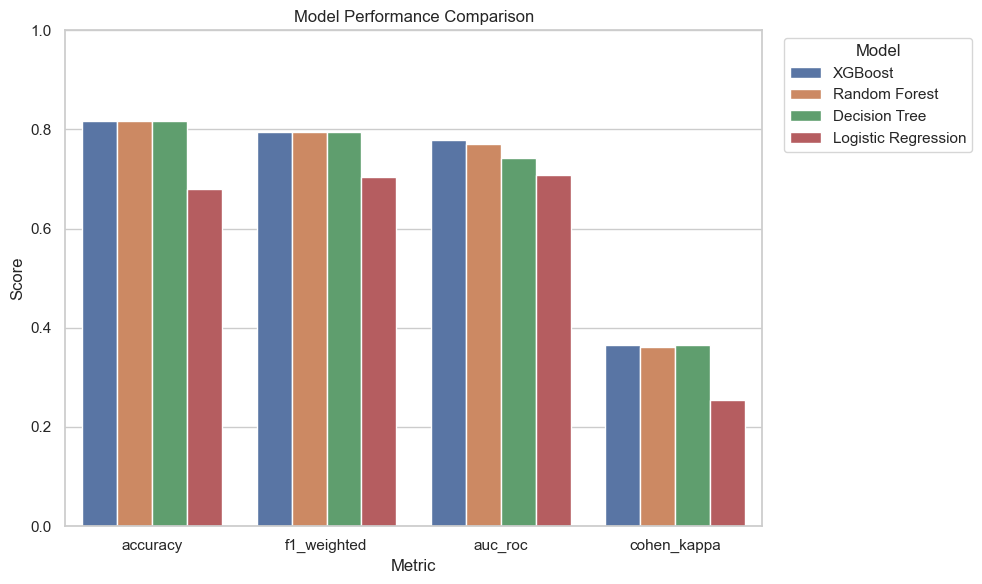

Saved performance comparison figure to ../paper/figures/m2_performance_comparison.png


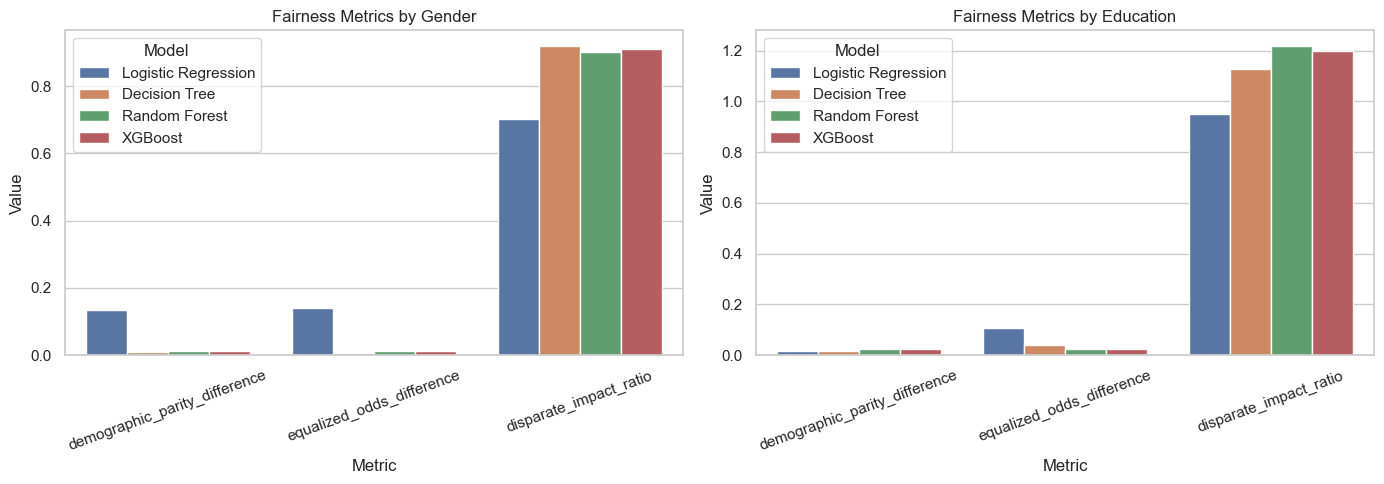

Saved fairness metrics figure to ../paper/figures/m2_fairness_metrics.png


In [14]:
# Cell 14: Create and save evaluation figures
performance_plot_df = standard_metrics_df.melt(
    id_vars="model",
    value_vars=["accuracy", "f1_weighted", "auc_roc", "cohen_kappa"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=performance_plot_df, x="metric", y="value", hue="model")
plt.title("Model Performance Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
performance_figure_path = figures_dir / "m2_performance_comparison.png"
plt.savefig(performance_figure_path, dpi=150, bbox_inches="tight")
assert performance_figure_path.exists(), "Performance comparison figure was not saved correctly."
plt.show()
print(f"Saved performance comparison figure to {performance_figure_path}")

fairness_plot_df = pd.concat([
    fairness_gender_df.assign(grouping="Gender"),
    fairness_education_df.assign(grouping="Education")
]).melt(
    id_vars=["model", "grouping"],
    value_vars=["demographic_parity_difference", "equalized_odds_difference", "disparate_impact_ratio"],
    var_name="metric",
    value_name="value"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for axis, grouping in zip(axes, ["Gender", "Education"]):
    subset = fairness_plot_df[fairness_plot_df["grouping"] == grouping]
    sns.barplot(data=subset, x="metric", y="value", hue="model", ax=axis)
    axis.set_title(f"Fairness Metrics by {grouping}")
    axis.set_xlabel("Metric")
    axis.set_ylabel("Value")
    axis.tick_params(axis="x", rotation=20)
    axis.legend(title="Model")

plt.tight_layout()
fairness_figure_path = figures_dir / "m2_fairness_metrics.png"
plt.savefig(fairness_figure_path, dpi=150, bbox_inches="tight")
assert fairness_figure_path.exists(), "Fairness metrics figure was not saved correctly."
plt.show()
print(f"Saved fairness metrics figure to {fairness_figure_path}")


> **Key insight for the report:** The purpose of the evaluation figures is to expose trade-offs, not to decorate the notebook. If the best-performing model also exhibits wider parity gaps, that tension is the result that matters.

### Phase 5 Summary

On the holdout set, **XGBoost** delivered the strongest predictive performance with **AUC = 0.7784**, **accuracy = 0.8175**, and **weighted F1 = 0.7976**. Random Forest ranked second, followed by Decision Tree and then Logistic Regression.

The fairness results differ by protected attribute. For **gender**, Decision Tree produced the mildest reported disparities, with a disparate impact ratio of **0.9199** and smaller parity gaps than the other models. Logistic Regression was clearly the weakest on gender fairness, with a disparate impact ratio of **0.7031**, which falls below the `0.8` screening threshold.

For **education**, the pattern is different: all four models produced disparate impact ratios above `1.0`, with XGBoost reaching **1.2196**. That does not mean the models are automatically fair; it means the direction of the positive classification rate differs from the gender case, reinforcing that fairness metrics must be interpreted by attribute rather than treated as one universal score.

## 6. Deployment

In this project context, deployment means packaging the notebook results for group synthesis and drafting a report-ready interpretation of the findings.

### Deployment Cell 1

**What this cell achieves:** Verifies that all required Member 2 exports exist at the agreed paths for the group synthesis notebook.

**Expected output:** A printed checklist of the required artifacts and a confirmation message when all assertions pass.

In [15]:
# Cell 15: Verify all required Member 2 exports for group synthesis
required_artifacts = [
    Path("../data/results/m2_standard_metrics.csv"),
    Path("../data/results/m2_fairness_gender.csv"),
    Path("../data/results/m2_fairness_education.csv"),
    Path("../paper/figures/m2_demographic_distributions.png"),
    Path("../paper/figures/m2_target_by_demographics.png"),
    Path("../paper/figures/m2_fairness_metrics.png"),
    Path("../paper/figures/m2_performance_comparison.png")
]

for artifact_path in required_artifacts:
    assert artifact_path.exists(), f"Missing required artifact: {artifact_path}"
    print(f"Verified: {artifact_path}")

print("All required Member 2 artifacts are present for group synthesis.")


Verified: ../data/results/m2_standard_metrics.csv
Verified: ../data/results/m2_fairness_gender.csv
Verified: ../data/results/m2_fairness_education.csv
Verified: ../paper/figures/m2_demographic_distributions.png
Verified: ../paper/figures/m2_target_by_demographics.png
Verified: ../paper/figures/m2_fairness_metrics.png
Verified: ../paper/figures/m2_performance_comparison.png
All required Member 2 artifacts are present for group synthesis.


> **Key insight for the report:** Reproducibility in a group project means more than rerunning code. It also means exporting results in the exact shared contract so the synthesis notebook can compare domains without manual repair.

### Report Contribution Draft

The Credit Default benchmark shows that predictive strength and fairness do not align uniformly across protected attributes. XGBoost delivered the strongest overall classification performance on the holdout set, while Decision Tree produced the least severe fairness gaps for gender under the selected metrics. Logistic Regression performed worst on both overall predictive quality and gender disparate impact, falling below the `0.8` screening threshold.

The education results were materially different from the gender results. All four models produced disparate impact ratios above `1.0` for the binary education comparison, indicating that the direction and magnitude of group disparities depend on which protected attribute is being examined. This supports the broader project argument that fairness is not a single-number property and that classifier comparisons must be interpreted through multiple demographic lenses rather than one aggregate judgment.

### Deployment Summary

Member 2 outputs are now ready for the group synthesis notebook. The exported CSV files provide standard and fairness metrics using the shared schema, and the saved figures provide the required visual evidence for the finance-domain contribution.

The main points to carry into the group report are:

1. XGBoost was the strongest predictive model on this benchmark,
2. gender fairness was more problematic than the binary education fairness view, and
3. fairness conclusions depend on the protected attribute being audited rather than following the performance ranking automatically.